In [1]:
!pip install librosa matplotlib numpy soundfile


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (10, 3)


Dataset Loading

We use `librosa.example('trumpet')`, a short real-world audio clip bundled with librosa's example
dataset. It is fetched once and cached (`~/.cache/librosa` or similar), so there is no manual dataset
download step and the file itself is small.


In [12]:
audio_path = librosa.example('trumpet')
y_orig, sr_orig = librosa.load(audio_path, sr=None)

print(f"File: {audio_path}")
print(f"Native sample rate: {sr_orig} Hz")
print(f"Duration: {len(y_orig) / sr_orig:.2f} s")
print(f"Number of samples: {len(y_orig)}")

display(Audio(y_orig, rate=sr_orig))


File: C:\Users\hp\AppData\Local\librosa\librosa\Cache\sorohanro_-_solo-trumpet-06.ogg
Native sample rate: 22050 Hz
Duration: 5.33 s
Number of samples: 117601


Preprocessing

Steps applied:
1. **Resampling** to a standard 16 kHz (common for speech/audio ML pipelines).
2. **Silence trimming** to remove leading/trailing silence.
3. **Amplitude normalization** to the range [-1, 1] (peak normalization).


In [15]:
TARGET_SR = 16000

y_resampled = librosa.resample(y_orig, orig_sr=sr_orig, target_sr=TARGET_SR)

y_trimmed, trim_index = librosa.effects.trim(y_resampled, top_db=25)

peak = np.max(np.abs(y_trimmed))
y_processed = y_trimmed / peak if peak > 0 else y_trimmed

sr_processed = TARGET_SR

print(f"Original duration: {len(y_orig)/sr_orig:.2f} s @ {sr_orig} Hz")
print(f"Processed duration: {len(y_processed)/sr_processed:.2f} s @ {sr_processed} Hz")
print(f"Trimmed samples removed: {len(y_resampled) - len(y_trimmed)}")
print(f"Peak amplitude before normalization: {peak:.4f}")
print(f"Peak amplitude after normalization: {np.max(np.abs(y_processed)):.4f}")

display(Audio(y_processed, rate=sr_processed))


Original duration: 5.33 s @ 22050 Hz
Processed duration: 3.07 s @ 16000 Hz
Trimmed samples removed: 36183
Peak amplitude before normalization: 0.6916
Peak amplitude after normalization: 1.0000


Visualization Helper

A single reusable function computes and plots: waveform, Mel-spectrogram, MFCC heatmap, and FFT spectrum
for a given signal, so we can call it identically on the original and preprocessed audio.


In [18]:
def visualize_audio(y, sr, title_prefix=""):
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    
    librosa.display.waveshow(y, sr=sr, ax=axes[0, 0])
    axes[0, 0].set_title(f"{title_prefix} Waveform")
    axes[0, 0].set_xlabel("Time (s)")
    axes[0, 0].set_ylabel("Amplitude")

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    img1 = librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[0, 1])
    axes[0, 1].set_title(f"{title_prefix} Mel-Spectrogram")
    fig.colorbar(img1, ax=axes[0, 1], format='%+2.0f dB')

    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    img2 = librosa.display.specshow(mfccs, sr=sr, x_axis='time', ax=axes[1, 0])
    axes[1, 0].set_title(f"{title_prefix} MFCC")
    axes[1, 0].set_ylabel("MFCC coefficients")
    fig.colorbar(img2, ax=axes[1, 0])

    n = len(y)
    fft_vals = np.fft.rfft(y)
    fft_freqs = np.fft.rfftfreq(n, d=1.0 / sr)
    fft_mag_db = 20 * np.log10(np.abs(fft_vals) + 1e-10)
    axes[1, 1].plot(fft_freqs, fft_mag_db, linewidth=0.7)
    axes[1, 1].set_title(f"{title_prefix} FFT Spectrum")
    axes[1, 1].set_xlabel("Frequency (Hz)")
    axes[1, 1].set_ylabel("Magnitude (dB)")

    plt.tight_layout()
    plt.show()

    return mel_spec_db, mfccs, fft_freqs, fft_mag_db


Original Audio Representations

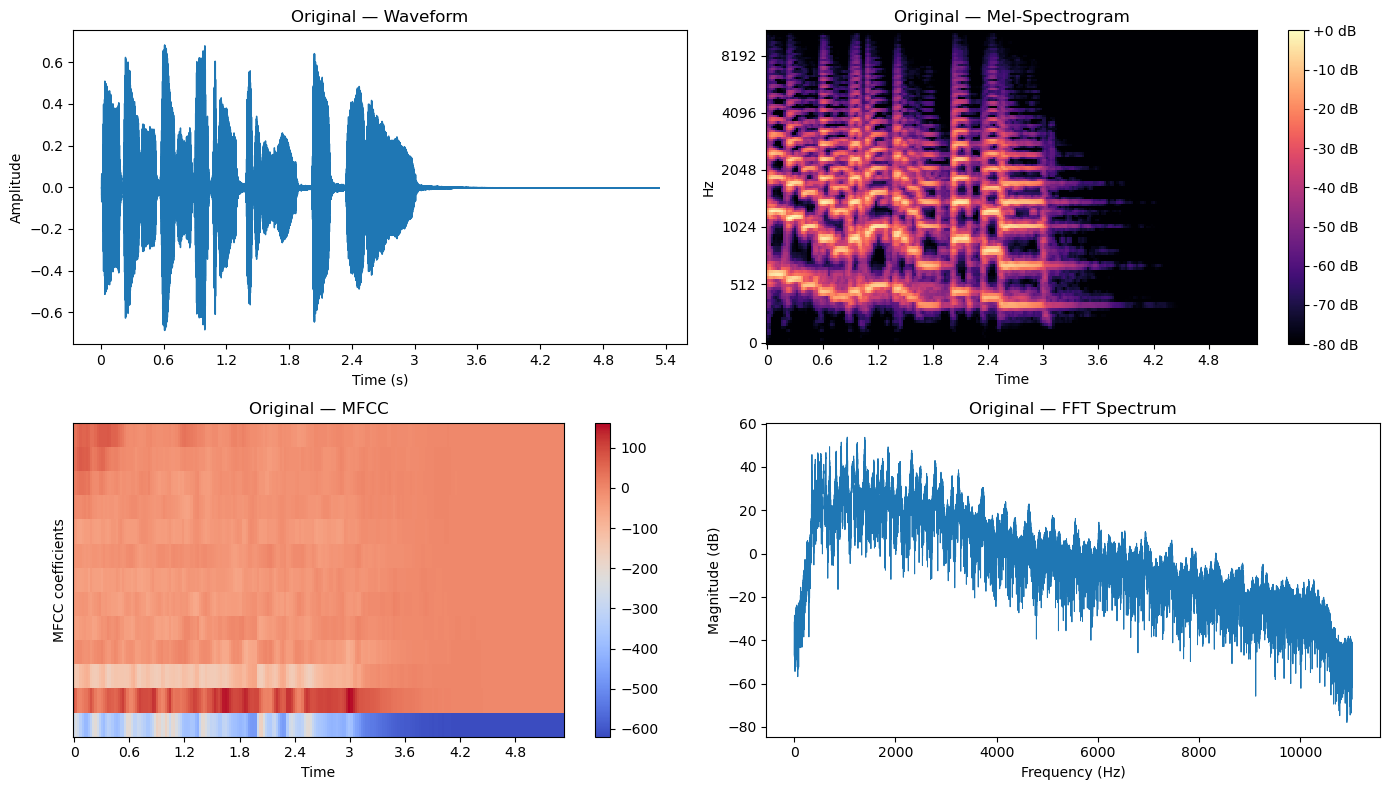

In [21]:
_ = visualize_audio(y_orig, sr_orig, title_prefix="Original —")

Preprocessed Audio Representations

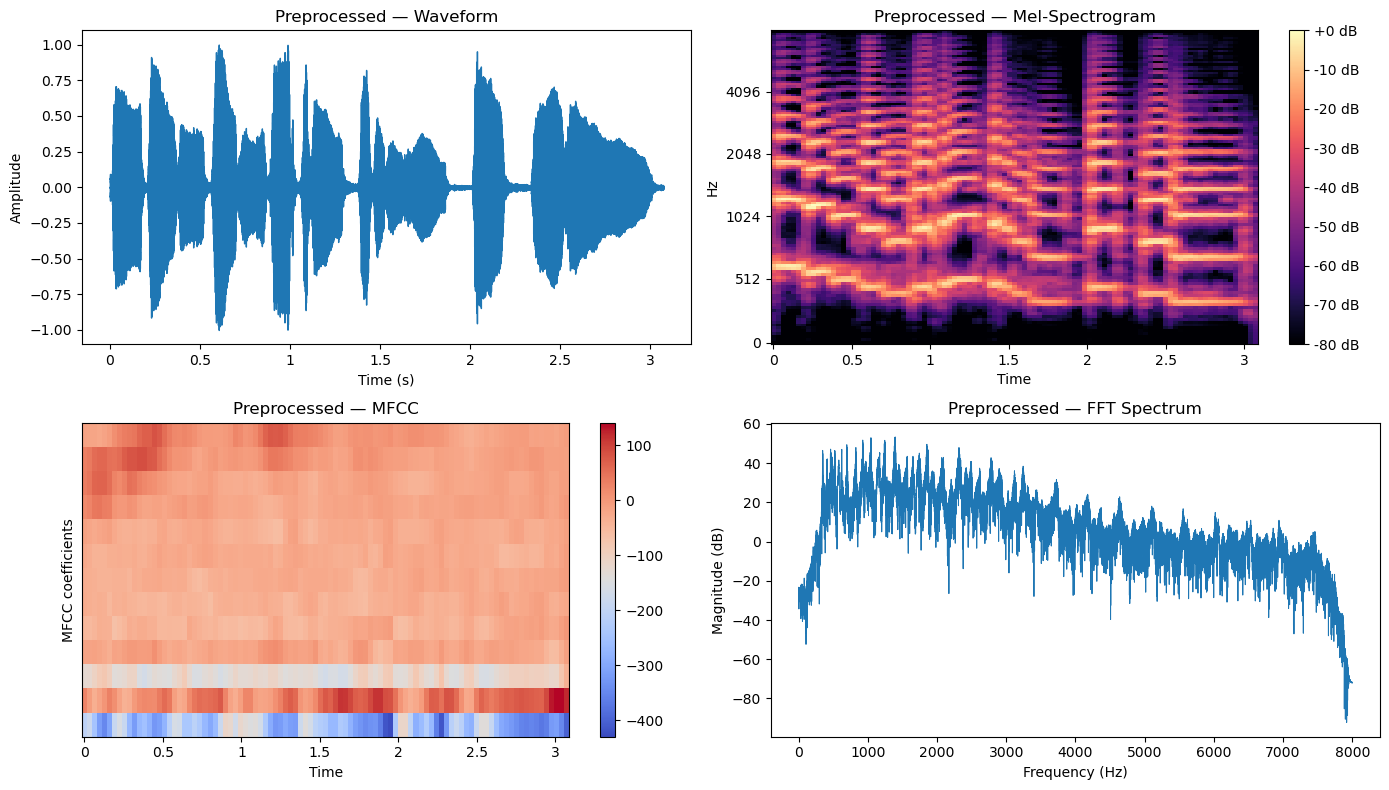

In [23]:
_ = visualize_audio(y_processed, sr_processed, title_prefix="Preprocessed —")

Side-by-Side Comparison

Direct comparison of waveform and Mel-spectrogram, original vs. preprocessed, in one figure.


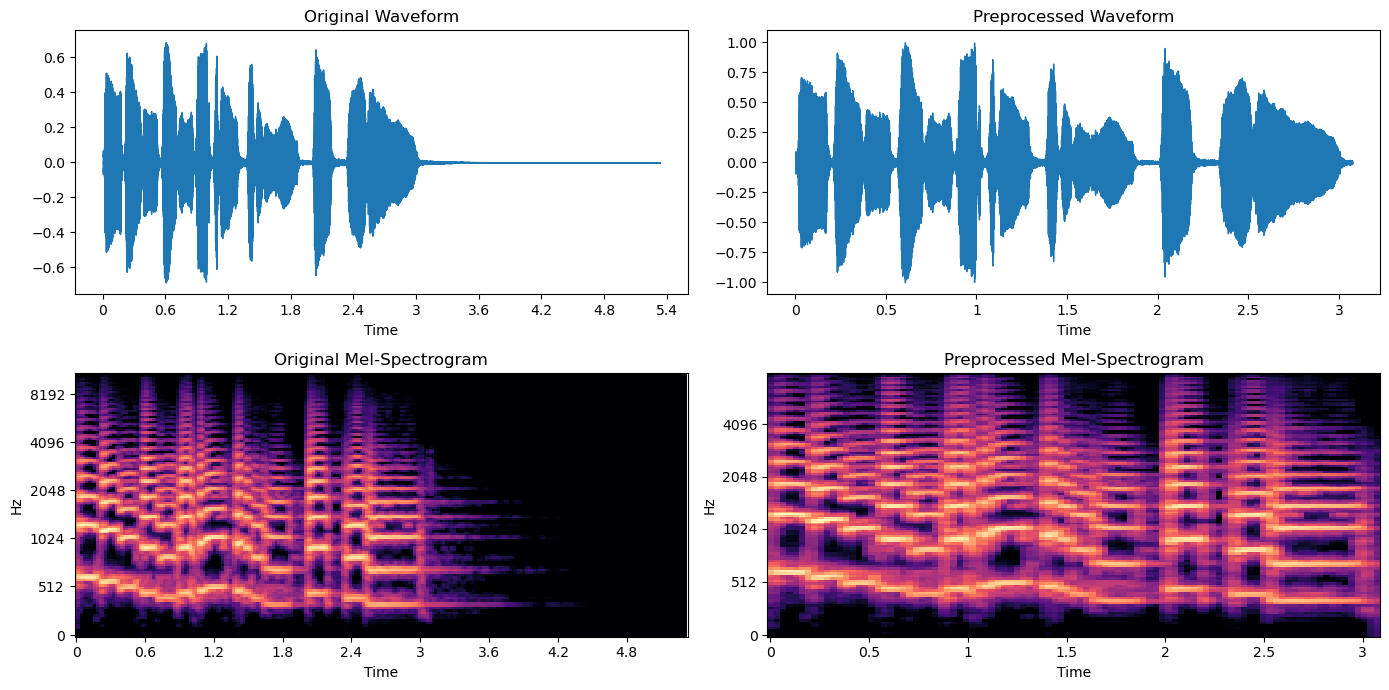

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

librosa.display.waveshow(y_orig, sr=sr_orig, ax=axes[0, 0])
axes[0, 0].set_title("Original Waveform")

librosa.display.waveshow(y_processed, sr=sr_processed, ax=axes[0, 1])
axes[0, 1].set_title("Preprocessed Waveform")

mel_orig_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y_orig, sr=sr_orig), ref=np.max)
mel_proc_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y_processed, sr=sr_processed), ref=np.max)

librosa.display.specshow(mel_orig_db, sr=sr_orig, x_axis='time', y_axis='mel', ax=axes[1, 0])
axes[1, 0].set_title("Original Mel-Spectrogram")

librosa.display.specshow(mel_proc_db, sr=sr_processed, x_axis='time', y_axis='mel', ax=axes[1, 1])
axes[1, 1].set_title("Preprocessed Mel-Spectrogram")

plt.tight_layout()
plt.show()


Waveform

Original clip is ~5.4s with a long trailing silence after ~3s (trumpet decay + dead air).
Preprocessed clip is trimmed to ~3.1s — the silence tail is gone, confirming trim worked.
Original peak amplitude is only ~±0.65; preprocessed is normalized to exactly ±1.0.

Mel-Spectrogram

Original spans up to ~8192 Hz (native sample rate), preprocessed only goes up to ~4096 Hz — expected, since resampling to 16 kHz halves the Nyquist frequency to 8 kHz.
Harmonic structure (horizontal bands = trumpet overtones) looks the same in both, just compressed in time after trimming.
The dead-silence region visible in the original spectrogram (dark area after ~3s) is absent in the preprocessed version.

MFCC

Lower coefficients (0–2) dominate with high positive values (red) — this reflects overall energy/timbre.
Higher coefficients turn slightly negative (blue), typical for MFCCs capturing finer spectral detail.

FFT Spectrum

Energy is concentrated between ~200 Hz–7000 Hz, consistent with a trumpet's harmonic range.
Sharp roll-off right at 8000 Hz confirms the 16 kHz resampling (Nyquist limit), matching your notebook's stated observation.